<a href="https://colab.research.google.com/github/Pinkraaaa/Lab_3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running on: cuda



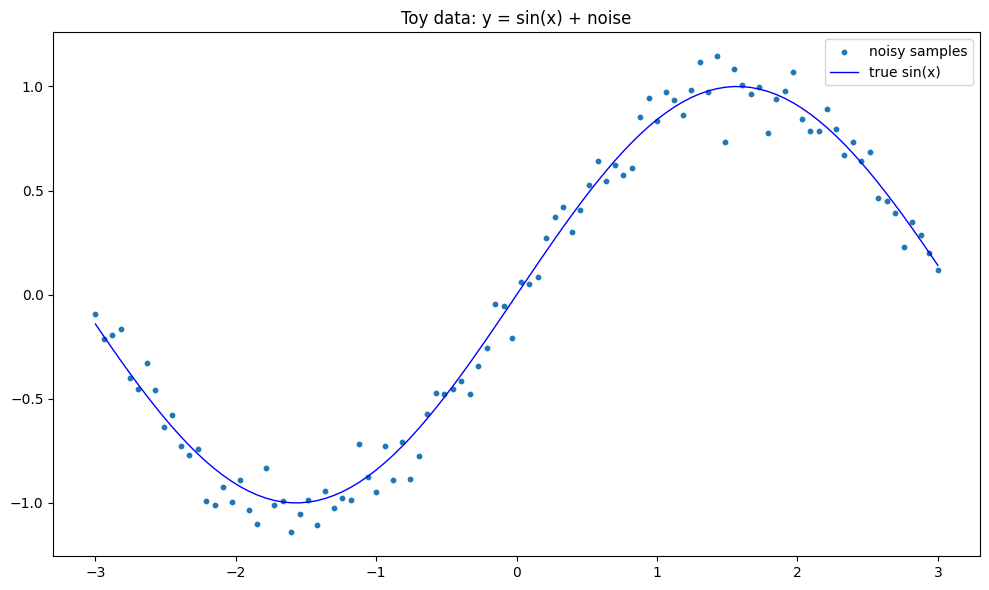


Final params: w = 0.34, b = -0.01, final loss = 0.20



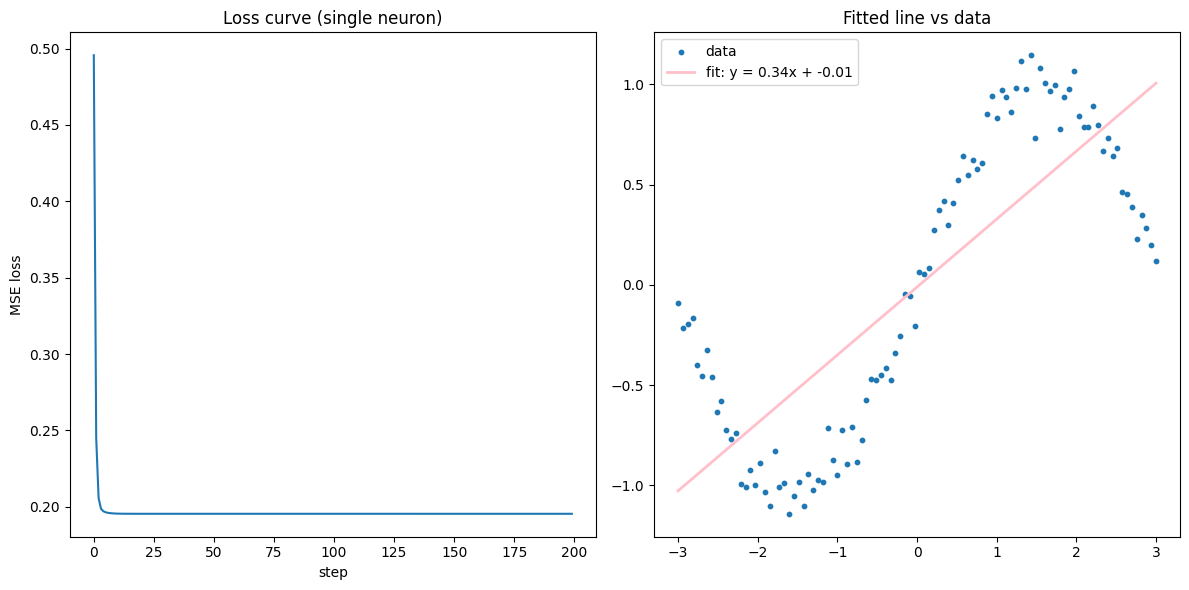

In [16]:
#PART 0 AND 1.1
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)
print()


#PART 1.1
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

np.random.seed(RANDOM_STATE)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size = x.shape)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s = 10, label = "noisy samples")
plt.plot(x, np.sin(x), color = "blue", lw = 1, label = "true sin(x)")
plt.title("Toy data: y = sin(x) + noise")
plt.legend()
plt.tight_layout()
plt.show()


# TODO: Initialise w and b to small random values.

rng = np.random.default_rng(RANDOM_STATE)
w = rng.normal(0, 0.1)
b = rng.normal(0, 0.1)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps
lr = 0.1
n_steps = 200
losses = []

for step in range(n_steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)          #MSE
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)         #dLoss/dw
    db = np.mean(2 * (y_hat - y))             #dLoss/db

    w -= lr * dw
    b -= lr * db

print()
print(f"Final params: w = {w:.2f}, b = {b:.2f}, final loss = {losses[-1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize = (12, 6))
axes[0].plot(losses)
axes[0].set_title("Loss curve (single neuron)")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
print()



#(b) the data with the fitted line on top.
axes[1].scatter(x, y, s = 10, label = "data")
axes[1].plot(x, w * x + b, color = "pink", lw = 2, label = f"fit: y = {w:.2f}x + {b:.2f}")
axes[1].set_title("Fitted line vs data")
axes[1].legend()
plt.tight_layout()
plt.show()


